<a href="https://colab.research.google.com/github/AdwaaNasser/DataMiningProject/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Report

This notebook presents the final stage of our data mining project on **air pollution and air quality levels**.  
In this phase, we:

- Introduce the problem we are trying to solve.  
- Formalize it as a data mining task (classification and clustering).  
- Describe the dataset and its main attributes.  
- Summarize the preprocessing steps that were applied to prepare the data for later modeling.


## 1. Problem

Air pollution is one of the most critical environmental problems affecting public health and quality of life.  
Exposure to high levels of pollutants such as **PM2.5, PM10, NO₂, SO₂, and CO** increases the risk of respiratory diseases, heart problems, and other long‑term complications.

However, it is not always easy to understand how different environmental factors (temperature, humidity, population density, proximity to industrial areas, etc.) interact and contribute to air quality. Raw measurements alone are difficult to interpret, and it is hard to identify when air quality becomes dangerous without proper analysis.

In this project, our goal is to **analyze air quality data and prepare it for data mining techniques**. The cleaned and transformed dataset will later be used to:

- Study how different pollutants and environmental variables are related.
- Compare air quality across different locations or conditions.
- Build models that can classify or group air quality levels to support decision‑making and early warnings.

This phase focuses on summarizing the data and applying preprocessing so that the next phases (classification and clustering) are based on reliable and well‑prepared data.

## 2. Data Mining Task

The air quality problem in this project can be viewed as both a **classification** and a **clustering** task.

###Classification

- **Type:** Supervised learning  
- **Class attribute:** `Air Quality`  
- **Goal:** Predict the air quality category (e.g., *Good*, *Moderate*, *Poor*, *Hazardous*) using pollutant and environmental attributes.  
- **Input features include:**
  - `Temperature`
  - `Humidity`
  - `PM2.5`
  - `PM10`
  - `NO2`
  - `SO2`
  - `CO`
  - `Proximity_to_Industrial_Areas`
  - `Population_Density`

A classification model will allow us later to estimate the air quality level for new observations. This can support early warnings and help authorities focus on areas with potentially harmful conditions.

###Clustering

- **Type:** Unsupervised learning  
- **Goal:** Group records into clusters based **only** on the similarity of their feature values, without using the `Air Quality` label during training.

By applying clustering, we can:

- Discover natural groups of locations with similar pollution patterns.  
- Identify clusters representing highly polluted areas versus relatively clean ones.  
- Explore hidden structures that may not be obvious from simple visual inspection.

In summary, **classification** will be used later to predict a known label, while **clustering** is used to explore hidden structure in the data. Both tasks depend on the same cleaned and preprocessed dataset prepared in this phase.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


## 3. Data

In this section, we describe the air quality dataset used in the project and provide a basic summary of its attributes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original air quality dataset (same source used in Phase 2)
df = pd.read_csv("https://raw.githubusercontent.com/leenmq05/Xxxx/e26d89f2d5a15177f3b20571bf00e85b3219b78a/updated_pollution_dataset.csv")

print("Number of attributes:", len(df.columns))
print("Number of records:", len(df))
df.head()

Number of attributes: 10
Number of records: 5000


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [ ]:
# Attribute names and data types
attribute_info = pd.DataFrame({
    "Attribute Name": df.columns,
    "Data Type": df.dtypes.astype(str)
})
attribute_info

,Attribute Name,Data Type
Temperature,Temperature,float64
Humidity,Humidity,float64
PM2.5,PM2.5,float64
PM10,PM10,float64
NO2,NO2,float64
SO2,SO2,float64
CO,CO,float64
Proximity_to_Industrial_Areas,Proximity_to_Industrial_Areas,float64
Population_Density,Population_Density,int64
Air Quality,Air Quality,object


### 3.1 Attribute Description

The main attributes in the dataset are:

- **Temperature** (numeric): Ambient temperature in °C.  
- **Humidity** (numeric): Relative humidity percentage.  
- **PM2.5** (numeric): Fine particulate matter concentration.  
- **PM10** (numeric): Coarse particulate matter concentration.  
- **NO2** (numeric): Nitrogen dioxide concentration.  
- **SO2** (numeric): Sulfur dioxide concentration.  
- **CO** (numeric): Carbon monoxide concentration.  
- **Proximity_to_Industrial_Areas** (numeric): Distance or closeness to industrial zones.  
- **Population_Density** (numeric): Number of people per area unit.  
- **Air Quality** (categorical): Overall air quality category (e.g., *Good*, *Moderate*, *Poor*, *Hazardous*).

The dataset mainly consists of numeric pollutant and weather measurements plus one class label representing the air quality level.

### 3.2 Five‑Number Summary

We computed the five‑number summary (minimum, first quartile Q1, median, third quartile Q3, and maximum) for the main numeric attributes to understand their distributions.


In [ ]:
numeric_cols = ['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO',
                'Proximity_to_Industrial_Areas','Population_Density']

summary = df.describe()[numeric_cols].T
five_number_summary = summary[['min', '25%', '50%', '75%', 'max']]
five_number_summary

,min,25%,50%,75%,max
Temperature,13.40,25.10,29.00,34.000,58.60
Humidity,36.00,58.30,69.80,80.300,128.10
PM2.5,0.00,4.60,12.00,26.100,295.00
PM10,-0.20,12.30,21.70,38.100,315.80
NO2,7.40,20.10,25.30,31.900,64.90
SO2,-6.20,5.10,8.00,13.725,44.90
CO,0.65,1.03,1.41,1.840,3.72
Proximity_to_Industrial_Areas,2.50,5.40,7.90,11.100,25.80
Population_Density,188.00,381.00,494.00,600.000,957.00


**Interpretation of Five‑Number Summary:**  

- **Temperature** ranges from relatively mild to very hot values, with a median around the upper twenties, which suggests generally warm conditions.  
- **Humidity** values are mostly in the moderate to high range, indicating that many observations come from humid environments.  
- **PM2.5 and PM10** show relatively low median values but very high maximum values, which means that there are occasional severe pollution events.  
- **NO2, SO2, and CO** usually remain at moderate levels but also contain some extreme values, especially in highly polluted areas.  
- **Proximity_to_Industrial_Areas** varies across locations, while **Population_Density** shows that some areas are much more crowded than others.

These observations confirm that the dataset contains both typical conditions and some strong outliers, especially for pollutant attributes.

In [ ]:
variance = df[numeric_cols].var(numeric_only=True)
variance

,0
Temperature,45.167289
Humidity,251.653065
PM2.5,602.925723
PM10,747.978707
NO2,79.127365
SO2,45.566596
CO,0.298145
Proximity_to_Industrial_Areas,13.038915
Population_Density,23333.810156


The variance values show which attributes change a lot between observations:

- High variance in **PM2.5, PM10, SO2** indicates that pollution levels can fluctuate strongly over time or between locations.  
- **Temperature** and **Humidity** also vary but within a more limited range.  
- **Proximity_to_Industrial_Areas** and **Population_Density** capture structural differences between regions (urban vs. rural).

Knowing which attributes are highly variable helps in understanding which features may have stronger influence on air quality.


### 3.4 Class Label Distribution and Visualizations

We now inspect how many records fall into each air quality category and visualize some basic patterns.


/tmp/ipython-input-410848279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')


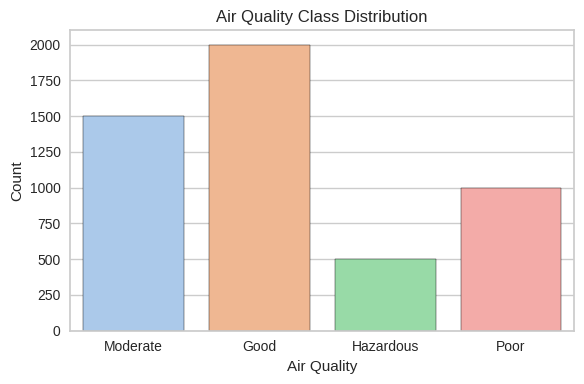

,count
Air Quality,
Good,2000
Moderate,1500
Poor,1000
Hazardous,500


In [ ]:
# Distribution of the class label (Air Quality)
plt.figure(figsize=(6,4))
sns.countplot(x='Air Quality', data=df, palette='pastel', edgecolor='black')
plt.title('Air Quality Class Distribution')
plt.xlabel('Air Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['Air Quality'].value_counts()

The class label distribution shows that most records belong to **Good** and **Moderate** air quality, while **Poor** and **Hazardous** conditions are less frequent.  
This means the dataset is slightly imbalanced, which should be considered later when building classification models.


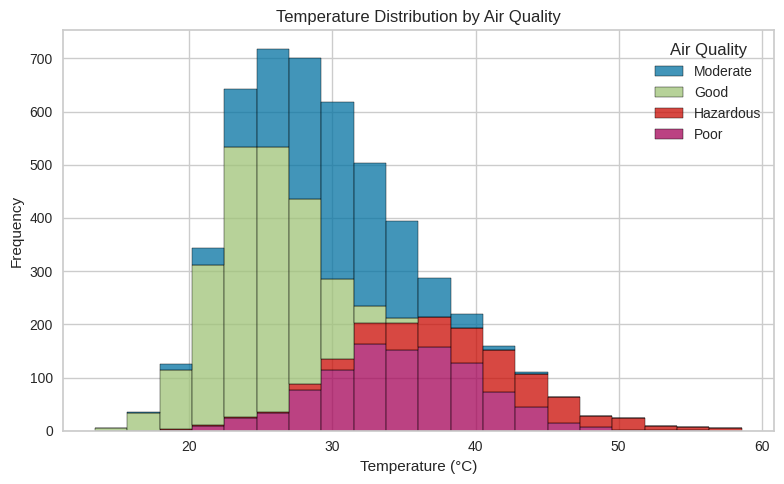

In [ ]:
# Example: histogram of Temperature by Air Quality
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Temperature', hue='Air Quality',
             multiple='stack', bins=20, edgecolor='black')
plt.title('Temperature Distribution by Air Quality')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

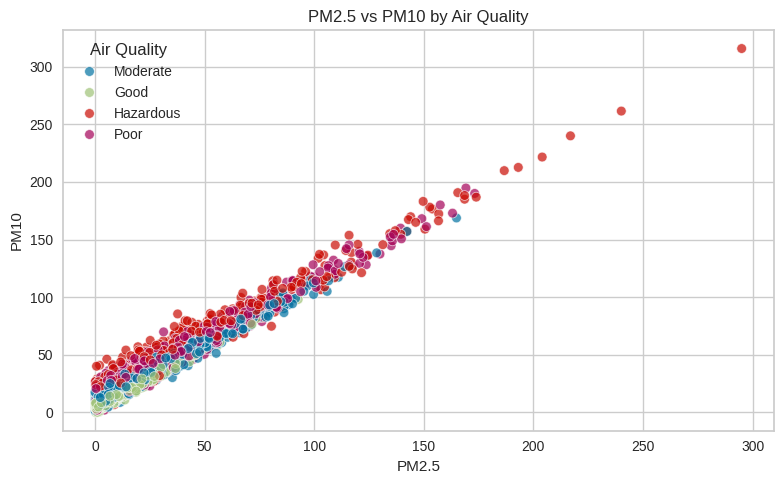

In [ ]:
# Example: scatter plot of PM2.5 vs PM10 colored by Air Quality
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='PM2.5', y='PM10', hue='Air Quality', alpha=0.7)
plt.title('PM2.5 vs PM10 by Air Quality')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.tight_layout()
plt.show()

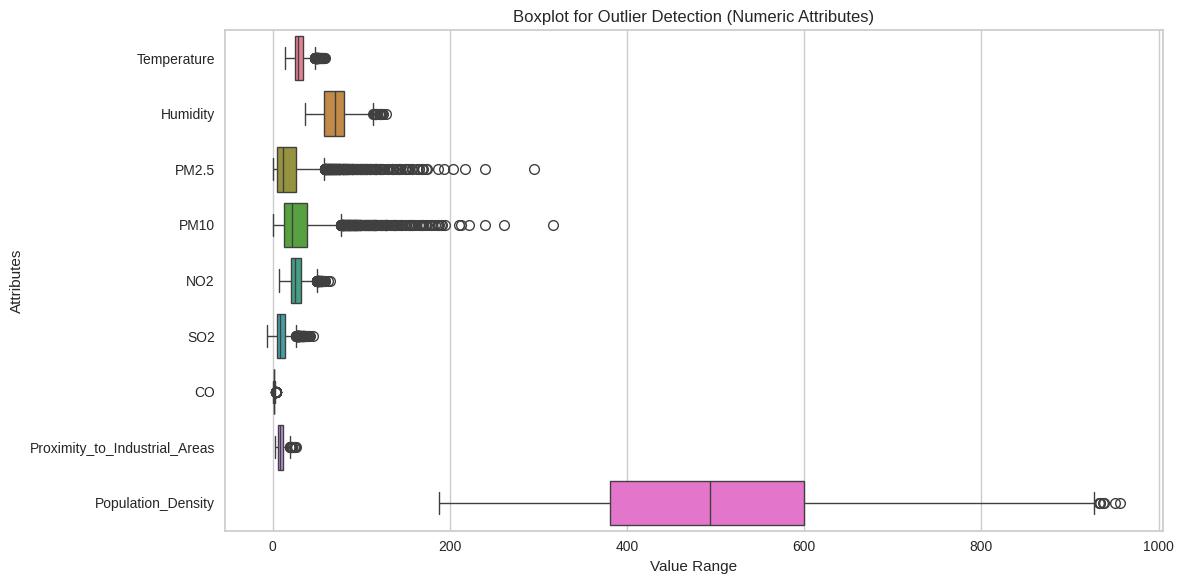

In [ ]:
# Boxplot for outlier inspection (all numeric columns)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title('Boxplot for Outlier Detection (Numeric Attributes)')
plt.xlabel('Value Range')
plt.ylabel('Attributes')
plt.tight_layout()
plt.show()

The plots above give a visual summary of the data:

- The **histogram** shows how temperature values are distributed across different air quality levels.  
- The **scatter plot** reveals the relationship between **PM2.5** and **PM10** and how it relates to the air quality classes.  
- The **boxplot** highlights the presence of outliers, especially in pollutant variables such as PM2.5 and PM10.


## 4. Data Pre‑processing

In this section, we summarize the preprocessing techniques applied to the air quality dataset in order to improve its quality and prepare it for later modeling.

### 4.1 Checking and Handling Missing Values

In [ ]:
# Check for missing values in each column
missing_count = df.isnull().sum()
missing_count

,0
Temperature,0
Humidity,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Proximity_to_Industrial_Areas,0
Population_Density,0
Air Quality,0


The results show **no missing values** in any attribute.  
Therefore, we did not need to apply imputation or remove any rows, and we were able to keep the full dataset intact.


### 4.2 Detecting and Removing Outliers (IQR Method)

In [ ]:
# Interquartile Range (IQR) method to count outliers
numeric_df = df[numeric_cols]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers_bool = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outliers_bool.sum()
outlier_counts

,0
Temperature,72
Humidity,19
PM2.5,352
PM10,324
NO2,73
SO2,124
CO,45
Proximity_to_Industrial_Areas,16
Population_Density,7


We observe that attributes such as **PM2.5**, **PM10**, and **SO2** contain a relatively large number of outliers.  
These extreme values can distort statistical summaries and may negatively affect some models, so we applied an outlier removal step using the IQR rule.


In [ ]:
# Function to remove outliers using IQR for a single column
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned = data[(data[column] >= lower) & (data[column] <= upper)]
    return cleaned

# Apply outlier removal
df_cleaned = df.copy()
for col in numeric_cols:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

print('Shape before outlier removal:', df.shape)
print('Shape after outlier removal :', df_cleaned.shape)

Shape before outlier removal: (5000, 10)
Shape after outlier removal : (4158, 10)


After removing outliers, the dataset becomes more stable and less influenced by extreme measurements.  
This helps the later analysis and data mining models to focus on typical pollution patterns rather than rare extreme cases.


### 4.3 Normalization (Min–Max Scaling)

In [ ]:
from copy import deepcopy

df_normalized = deepcopy(df_cleaned)

num_cols_all = df_normalized.select_dtypes(include='number').columns.tolist()

# If the class label is numeric we would exclude it here. For this dataset, Air Quality is categorical.
cols_to_scale = num_cols_all

df_normalized[cols_to_scale] = (
    (df_normalized[cols_to_scale] - df_normalized[cols_to_scale].min()) /
    (df_normalized[cols_to_scale].max() - df_normalized[cols_to_scale].min())
)

df_normalized[cols_to_scale].describe().T[['min','max']]

,min,max
Temperature,0.0,1.0
Humidity,0.0,1.0
PM2.5,0.0,1.0
PM10,0.0,1.0
NO2,0.0,1.0
SO2,0.0,1.0
CO,0.0,1.0
Proximity_to_Industrial_Areas,0.0,1.0
Population_Density,0.0,1.0


The table confirms that all numeric attributes used for modeling are now scaled between **0** and **1**.  
This step ensures that variables with originally large scales (such as population density) do not dominate those with smaller scales when distance‑based algorithms are applied.


### 4.4 Discretization of Selected Attributes

In [ ]:
# Discretize selected numeric columns into 3 bins (0 = low, 1 = medium, 2 = high)
columns_to_discretize = ['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO','Proximity_to_Industrial_Areas','Population_Density']
num_bins = 3
bin_edges_dict = {}
df_discretized = df_normalized.copy()
for column in columns_to_discretize: df_discretized[column], bin_edges = pd.cut(df_discretized[column],bins=num_bins,labels=False,retbins=True)
bin_edges_dict[column] = bin_edges

# Show first rows after discretization
df_discretized[columns_to_discretize].head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,1,0,0,0,0,1,1,0,0
1,1,1,0,0,1,1,1,0,1
2,0,1,1,1,1,1,1,0,1
3,1,0,0,0,0,1,0,1,1
4,1,1,0,0,1,1,0,1,0


After discretization, each selected attribute is represented by integer values (**0**, **1**, **2**),  
which correspond to automatically computed ranges (low, medium, high).  
This transformation simplifies interpretation and can be useful for some algorithms or rule‑based analysis.

# Data Mining Technique

In this project, two primary data mining techniques are applied to the preprocessed dataset: classification and clustering. Each method serves a different analytical purpose and contributes to discovering meaningful patterns within the data.



# Classification : Decision Tree Classifier

For the classification task, we employ the Decision Tree Classifier from the scikit-learn library. Decision Trees are selected because they:

-Are easy to interpret and visualize

-Can handle both numerical and categorical features

-Identify the most important attributes influencing predictions

-Provide clear, rule-based decision paths that enhance understanding of the dataset

**Why Decision Trees?**

They allow us to analyze how different attributes split the data into distinct classes, and they offer transparency in how predictions are made, which is essential for the interpretation step.

**How the model is applied**
we use:

from sklearn.tree import DecisionTreeClassifier

**Two attribute selection criteria are used:**

Gini index (default):

DecisionTreeClassifier(criterion="gini")


Information Gain (Entropy):

DecisionTreeClassifier(criterion="entropy")

**The classifier is trained and evaluated using three different train/test partitions:**

90% training – 10% testing

80% training – 20% testing

70% training – 30% testing

**Model performance is assessed using:**

Accuracy score

Confusion matrix

Visualization of the decision tree

**Packages used:**

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import plot_tree


# Evaluation and Comparison
**Classification :**

In [ ]:
data = pd.read_csv("Preprocessed_dataset.csv")

target_column = "Air Quality"

X = data.drop(columns=[target_column])
y = data[target_column]

# encoding categorical features:
X = pd.get_dummies(X)


In [ ]:
def run_decision_tree_experiments(X, y, criteria, splits, random_state=42):
    results = []

    for crit in criteria:
        for train_size in splits:
            test_size = 1 - train_size

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )

            clf = DecisionTreeClassifier(
                criterion=crit,
                max_depth=3,
                min_samples_leaf=5,
                random_state=random_state
            )

            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)

            results.append({
                "criterion": crit,
                "train_size": train_size,
                "test_size": test_size,
                "accuracy": acc,
                "confusion_matrix": cm,
                "model": clf,
                "y_test": y_test,
                "y_pred": y_pred
            })

    return results

criteria = ["gini", "entropy"]  # Gini index and Information Gain
splits = [0.9, 0.8, 0.7]        # 90/10, 80/20, 70/30

results = run_decision_tree_experiments(X, y, criteria, splits)

In [ ]:
# Build summary tables for each criterion

rows_gini = []
rows_entropy = []

for res in results:
    row = {
        "Train %": int(res["train_size"] * 100),
        "Test %": int(res["test_size"] * 100),
        "Accuracy": round(res["accuracy"], 4)
    }
    if res["criterion"] == "gini":
        rows_gini.append(row)
    else:
        rows_entropy.append(row)

gini_df = pd.DataFrame(rows_gini).sort_values(by="Train %", ascending=False)
entropy_df = pd.DataFrame(rows_entropy).sort_values(by="Train %", ascending=False)

print("=== Decision Tree with Gini Index ===")
display(gini_df)

print("=== Decision Tree with Information Gain (Entropy) ===")
display(entropy_df)


=== Decision Tree with Gini Index ===


,Train %,Test %,Accuracy
0,90,9,0.7940
1,80,19,0.7880
2,70,30,0.7828


=== Decision Tree with Information Gain (Entropy) ===


,Train %,Test %,Accuracy
0,90,9,0.7940
1,80,19,0.7590
2,70,30,0.7828


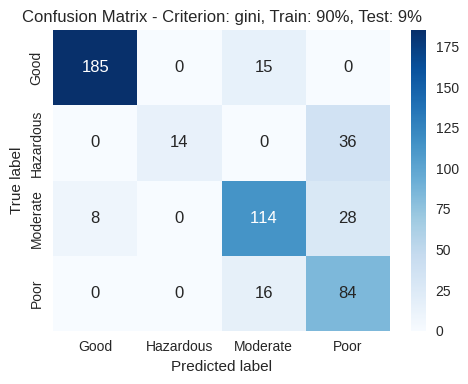

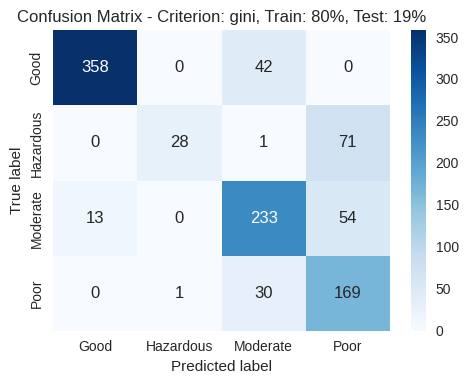

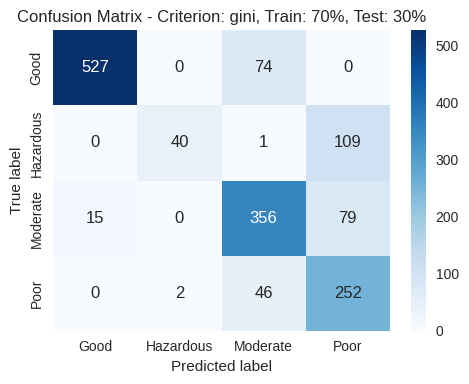

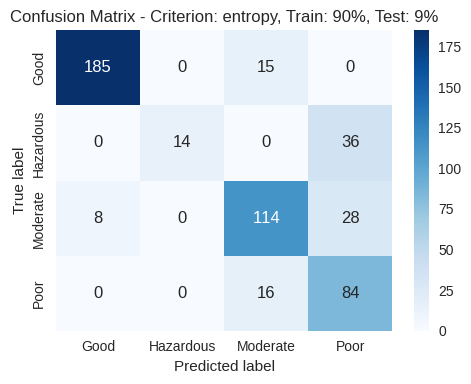

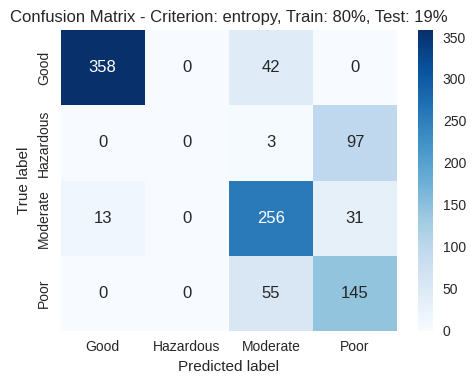

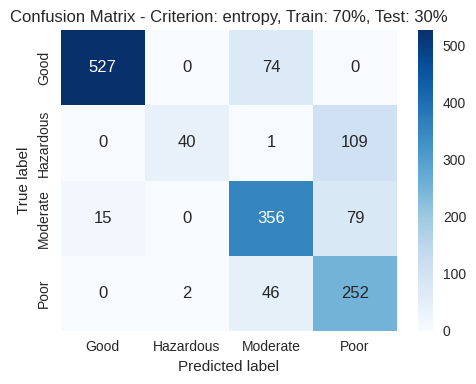

In [ ]:
# Plot confusion matrices for each criterion and split

labels = sorted(y.unique())

for res in results:
    crit = res["criterion"]
    train_p = int(res["train_size"] * 100)
    test_p = int(res["test_size"] * 100)
    cm = res["confusion_matrix"]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - Criterion: {crit}, Train: {train_p}%, Test: {test_p}%")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


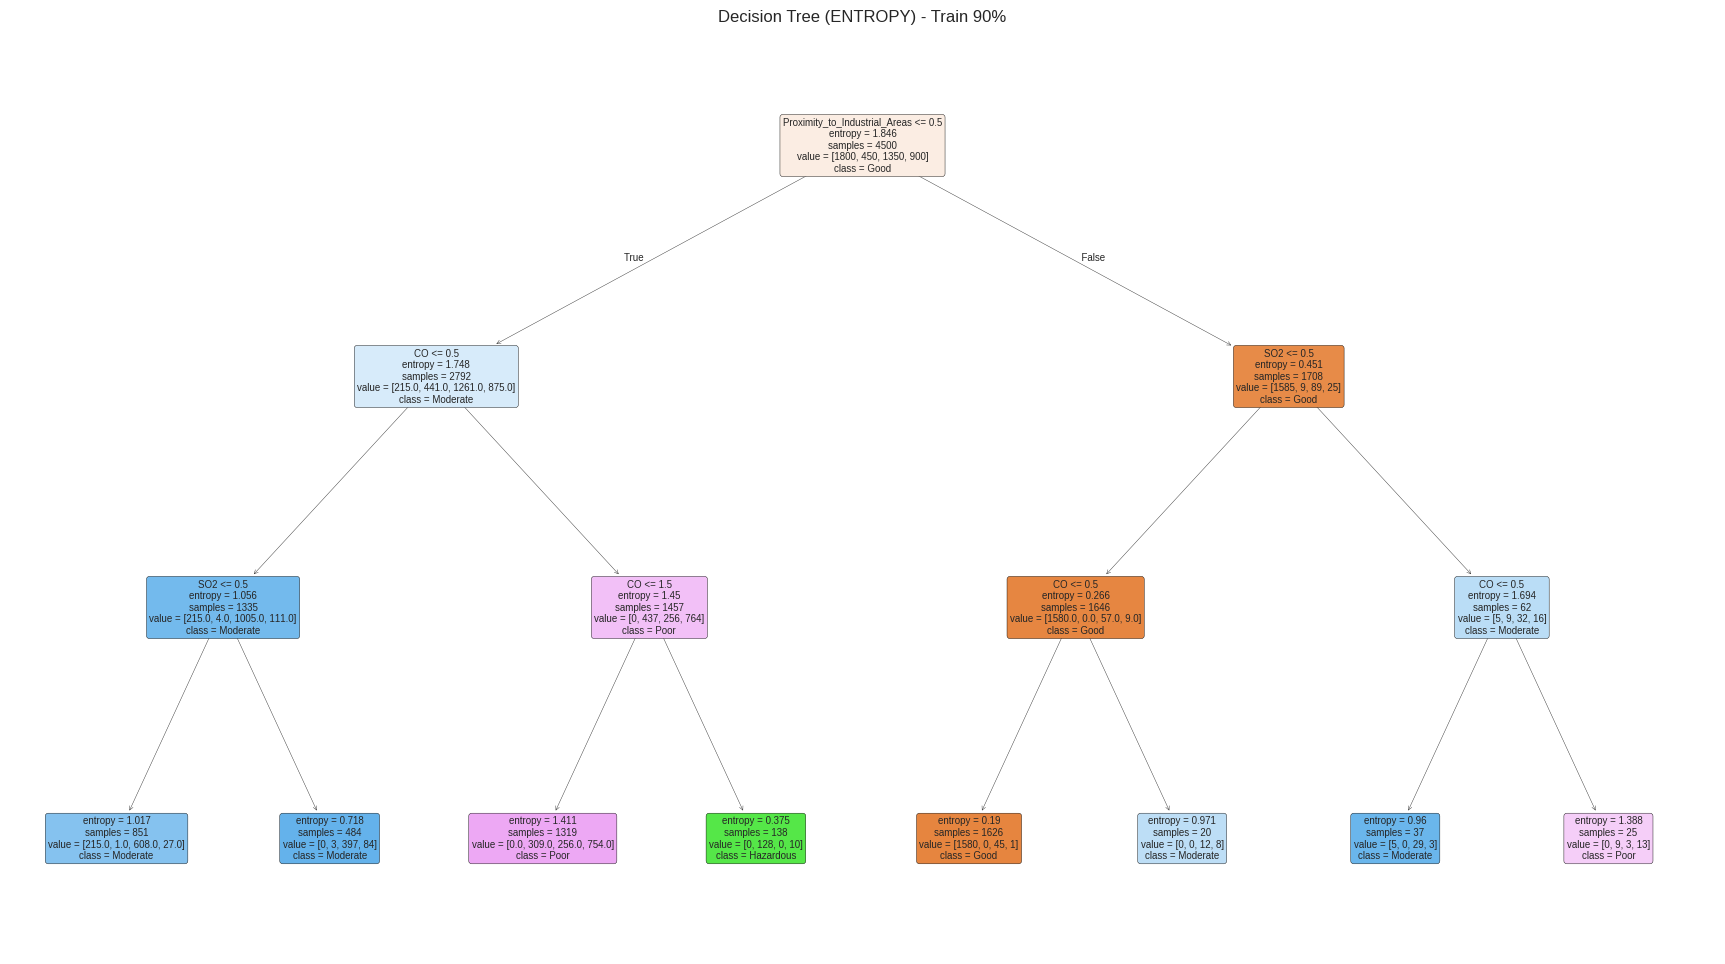

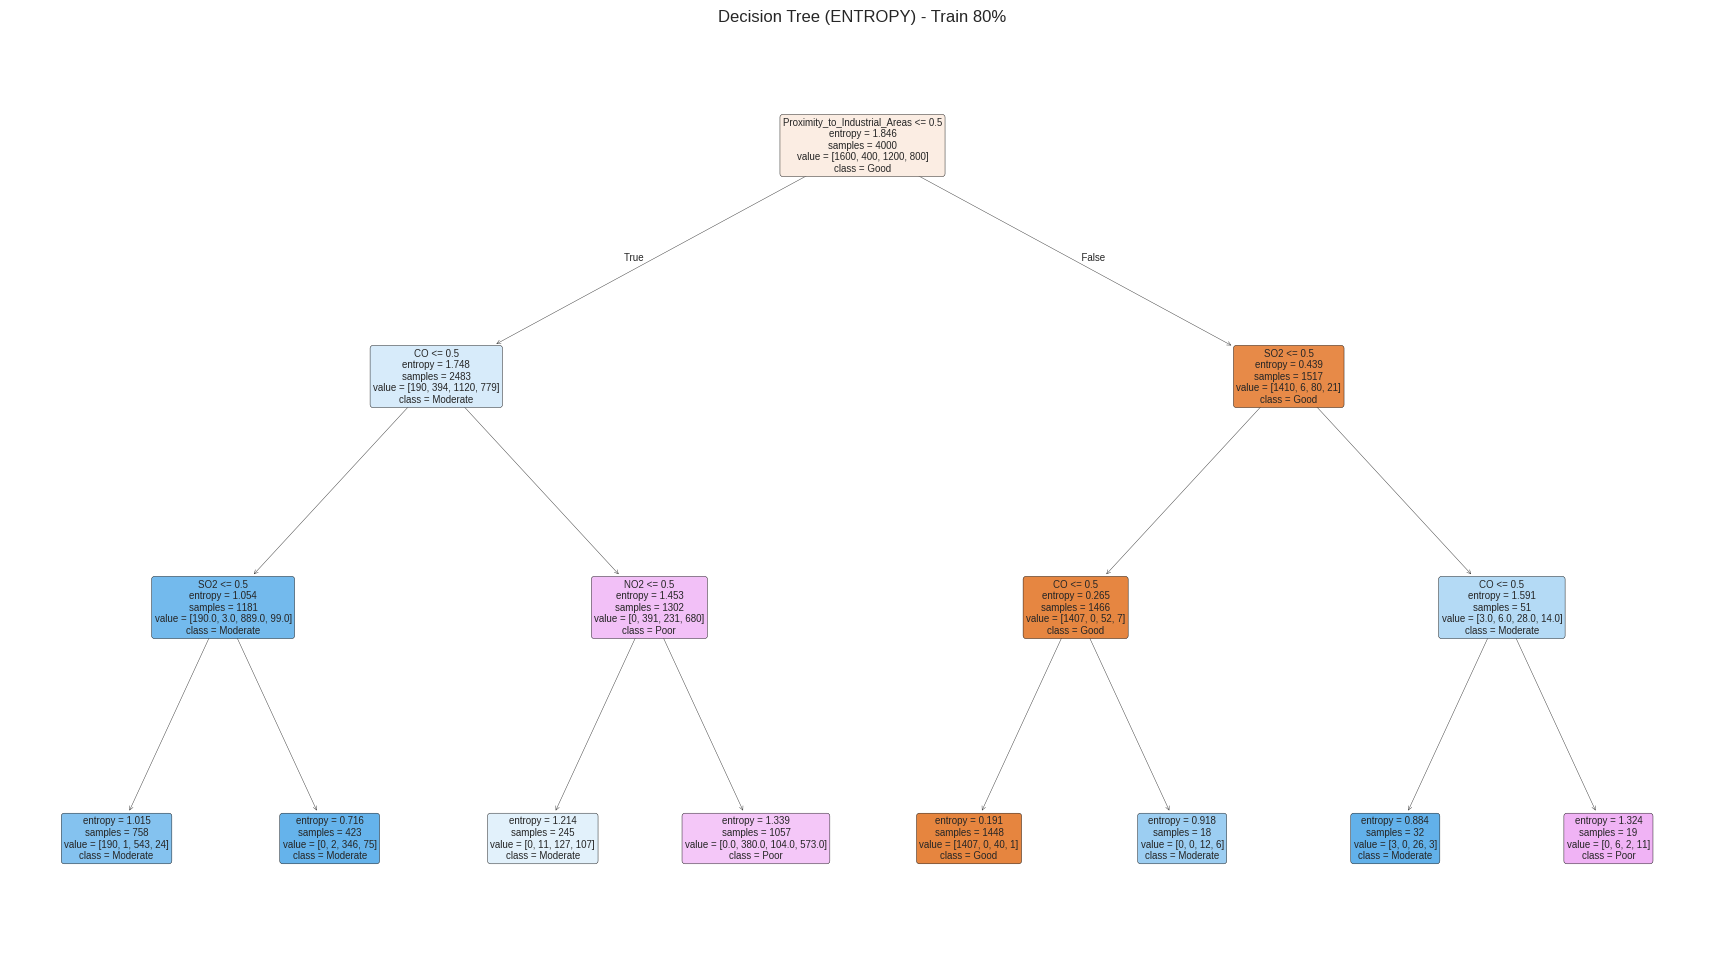

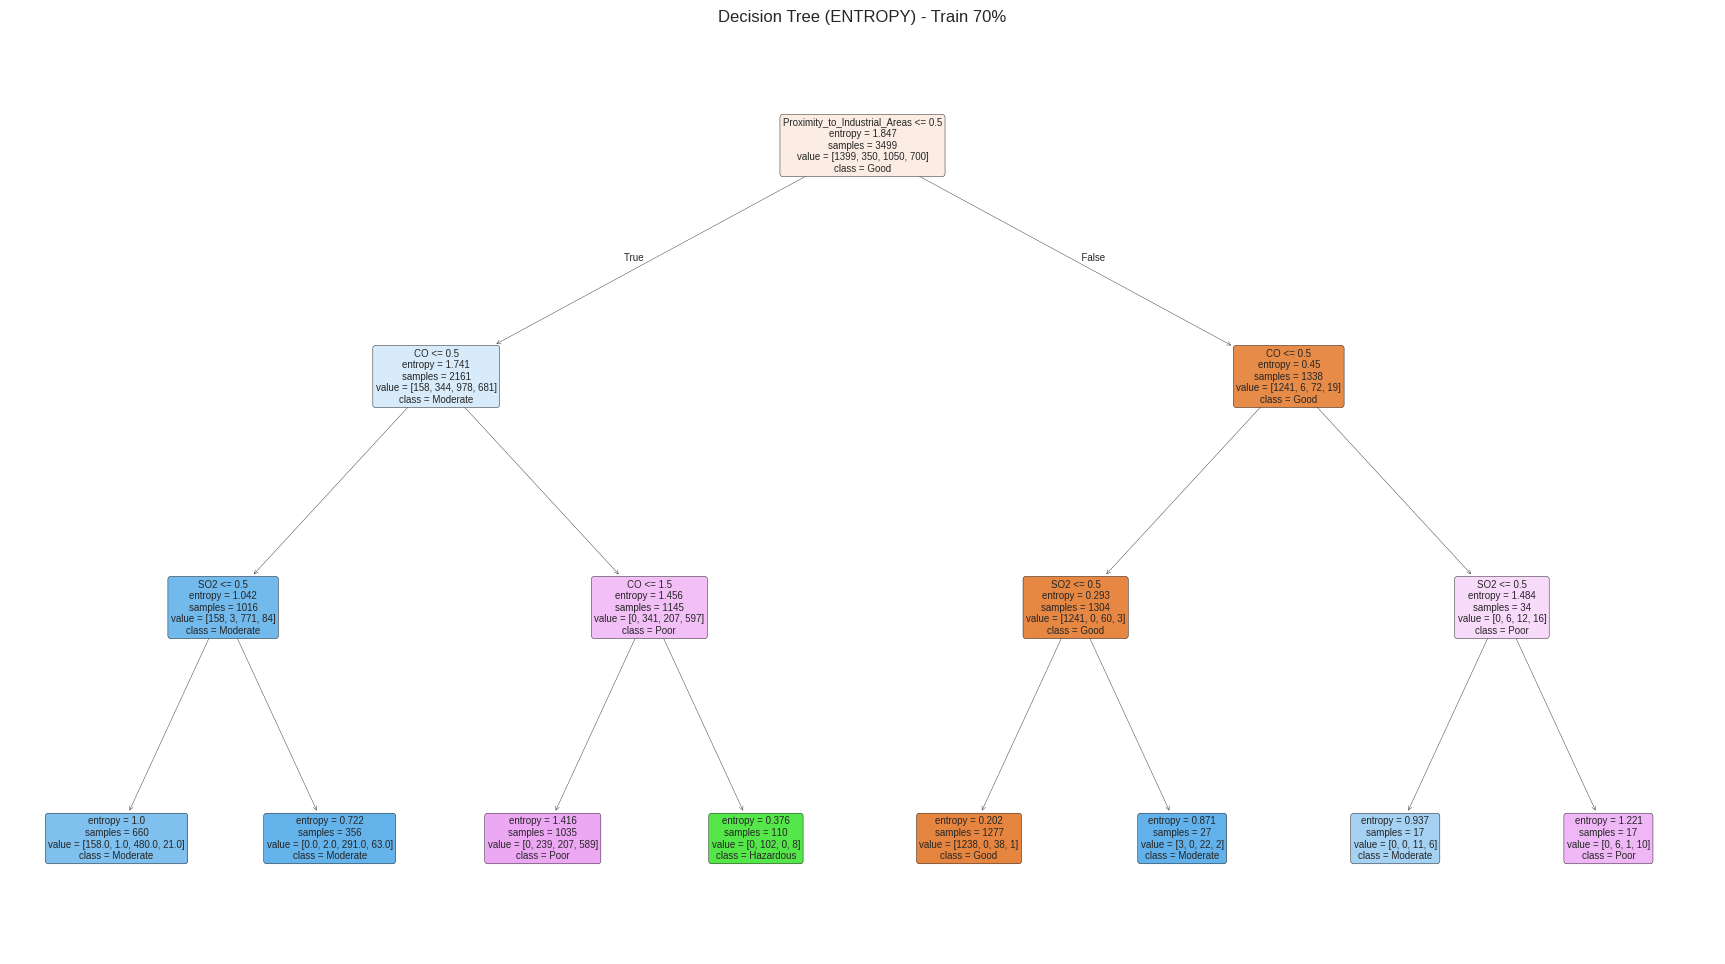

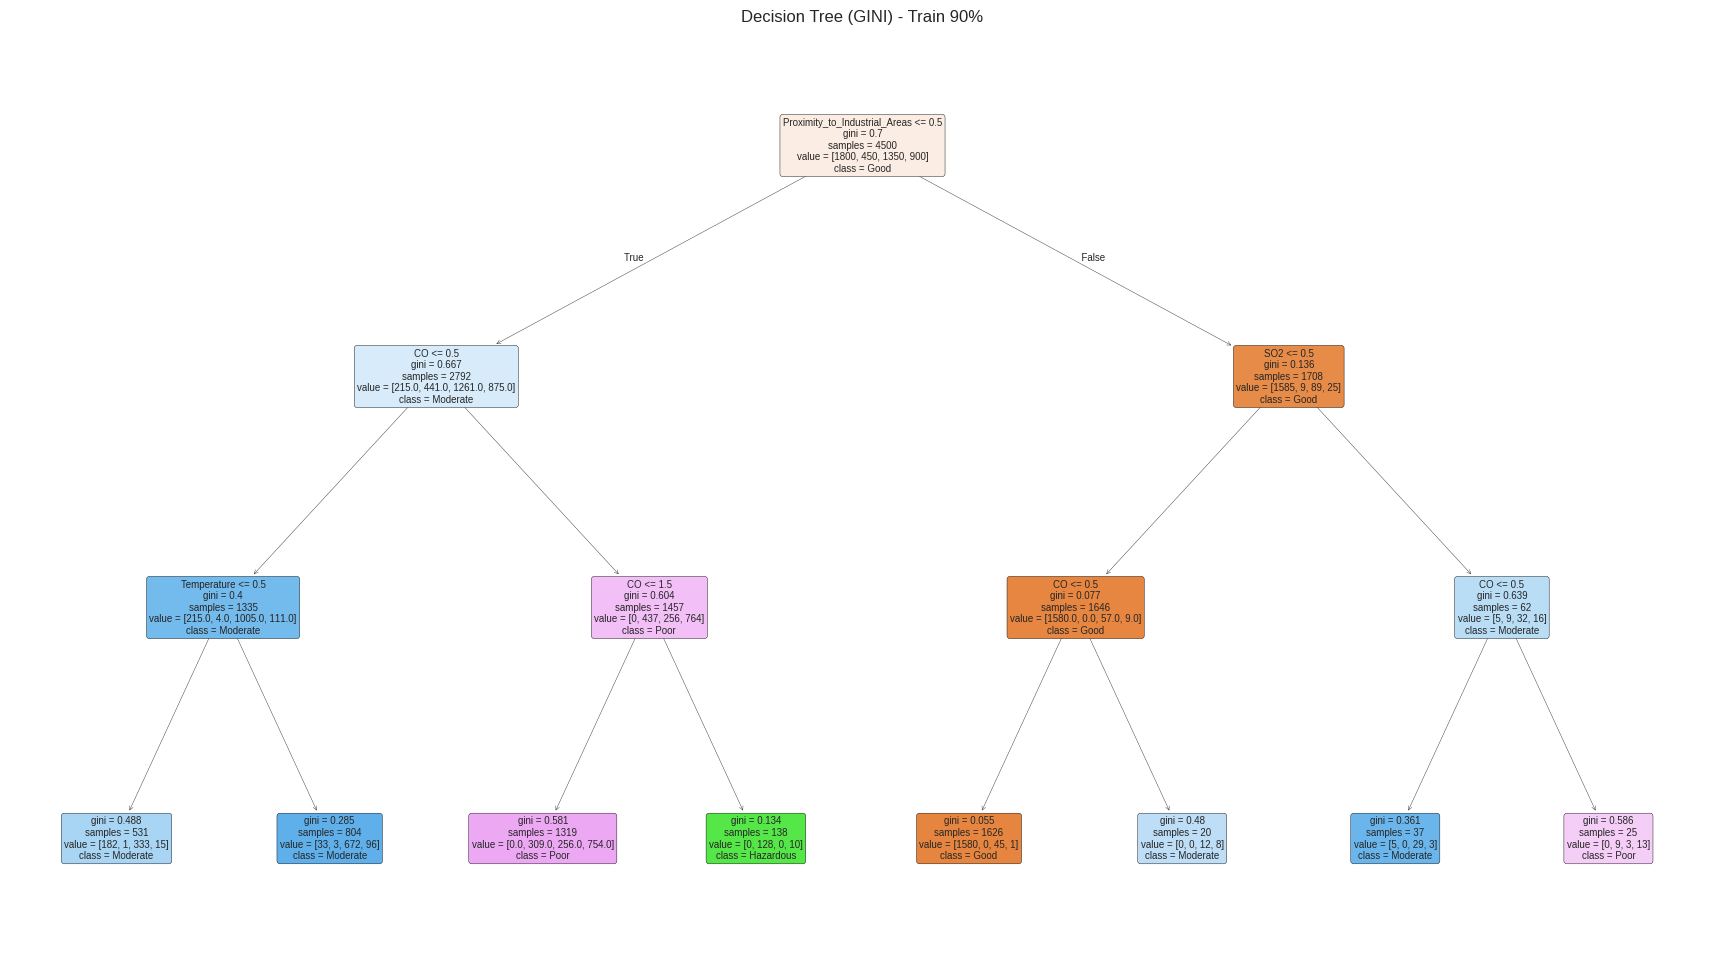

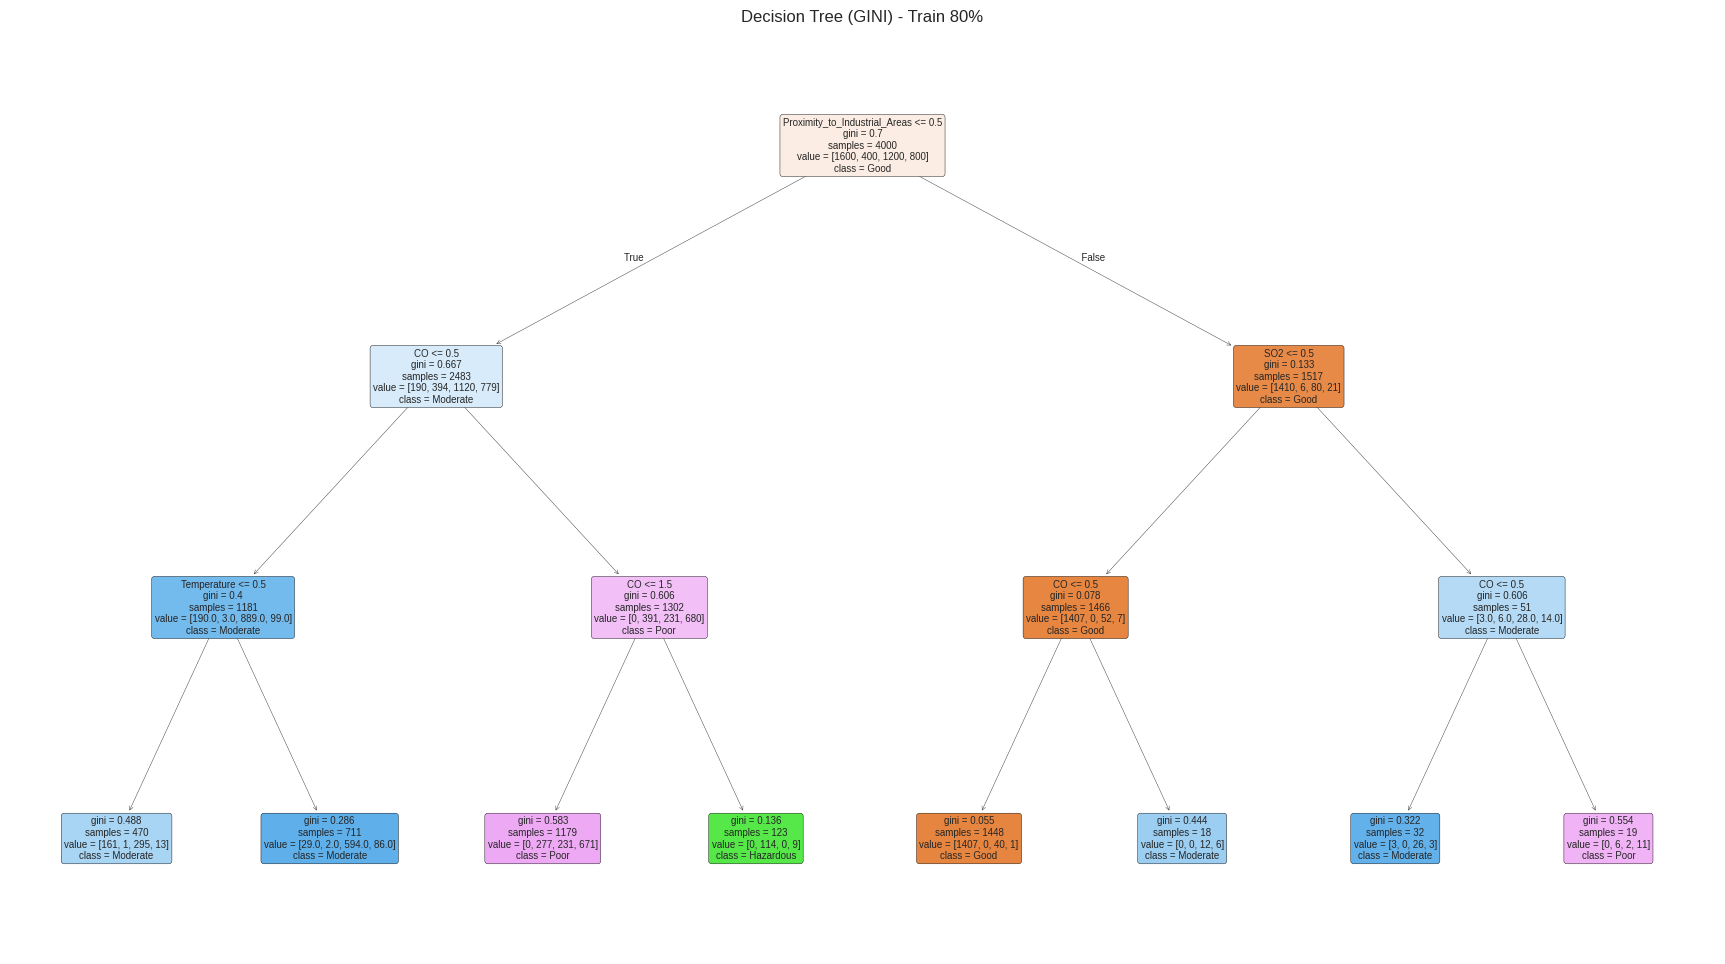

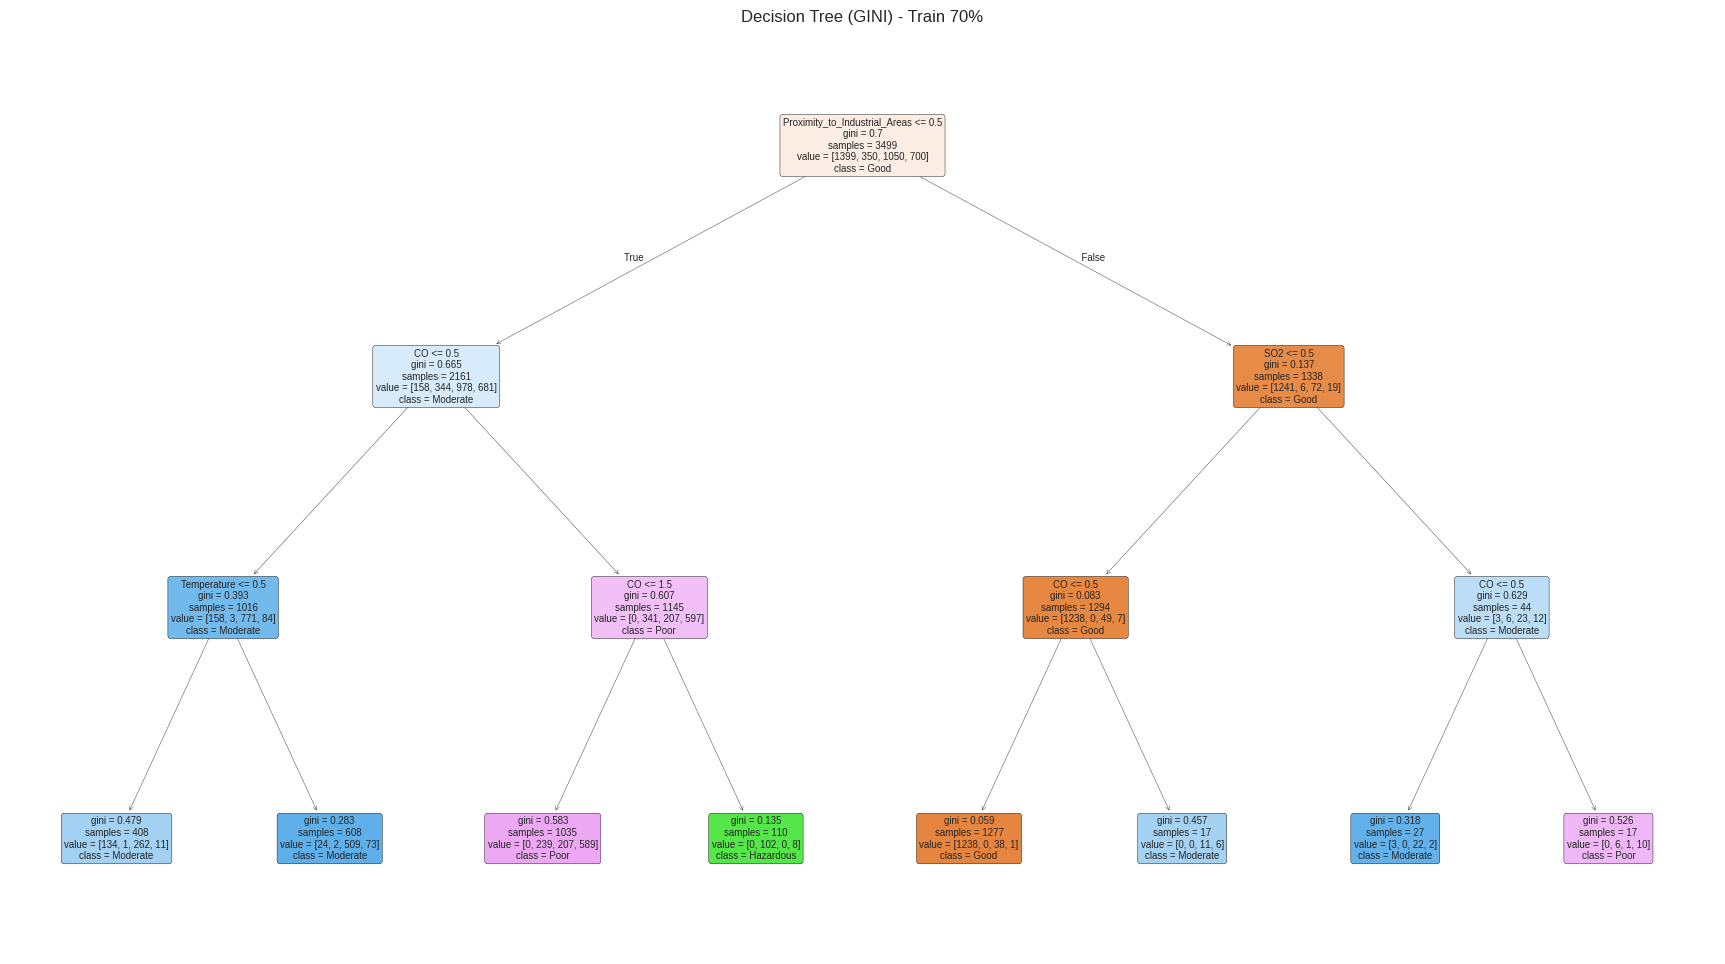

In [ ]:
def plot_dt(criterion, train_size):

    selected = None
    for res in results:
        if res["criterion"] == criterion and round(res["train_size"], 2) == round(train_size, 2):
            selected = res
            break

    if selected is None:
        print(f"Model not found: {criterion}, train_size={train_size}")
        return

    clf = selected["model"]


    plt.figure(figsize=(22, 12))
    plot_tree(
        clf,
        feature_names=X.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        fontsize=7
    )
    train_percent = int(train_size * 100)
    plt.title(f"Decision Tree ({criterion.upper()}) - Train {train_percent}%")
    plt.show()



#  3 entropy Trees
plot_dt("entropy", 0.9)
plot_dt("entropy", 0.8)
plot_dt("entropy", 0.7)

# 3 gini Trees

plot_dt("gini", 0.9)
plot_dt("gini", 0.8)
plot_dt("gini", 0.7)


# **Clustering**

In [ ]:

df = data.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode label if needed
if df['Air Quality'].dtype == 'object':
    le = LabelEncoder()
    df['Air Quality'] = le.fit_transform(df['Air Quality'])

# Remove target column
df_no_label = df.drop(columns=['Air Quality'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_no_label)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4]
results = []

print("📊 Results for K-means:\n")

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)

    wss = model.inertia_
    sil = silhouette_score(X_scaled, labels)

    results.append((k, wss, sil))
    print(f"K = {k} | WSS = {wss:.2f} | Silhouette = {sil:.4f}")

📊 Results for K-means:

K = 2 | WSS = 30967.25 | Silhouette = 0.3427
K = 3 | WSS = 22734.42 | Silhouette = 0.3576
K = 4 | WSS = 18871.12 | Silhouette = 0.3022


In [ ]:
# !pip install yellowbrick

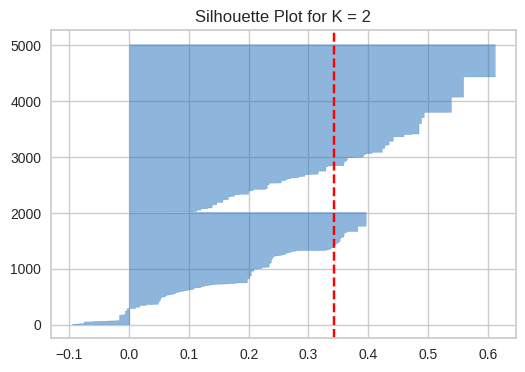

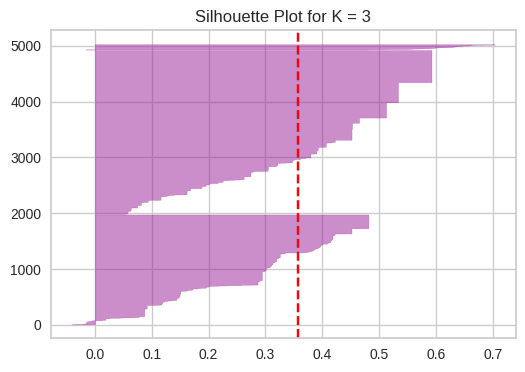

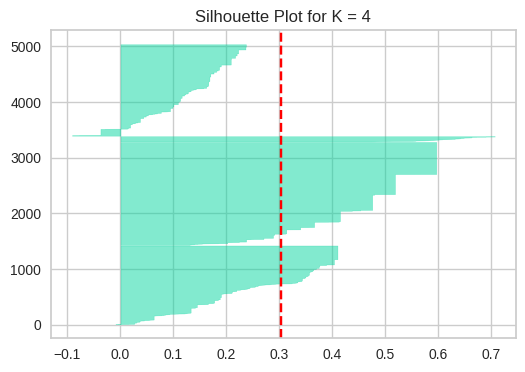

In [ ]:

from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

custom_colors = ["#1F6FBA", "#9A1F98", "#06D6A0"]  # Blue, Purple, Aqua

for i, k in enumerate(k_values):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    fig, ax = plt.subplots(figsize=(6,4))
    viz = SilhouetteVisualizer(model, colors=[custom_colors[i]], ax=ax)
    viz.fit(X_scaled)
    plt.title(f"Silhouette Plot for K = {k}")
    plt.show()

### Interpretation for K = 2
- Clusters are separated but broad.
- Moderate silhouette value → separation is acceptable but not ideal.
- Indicates that the dataset might need more than 2 clusters for better separation.

### Interpretation for K = 3
- Highest silhouette score among tested values.
- Best balance between cohesion (tight clusters) and separation.
- Groups are meaningful and well-distributed.
### Interpretation for K = 4
- Silhouette score drops compared to K=3.
- Splitting data into too many clusters → causes overlap and reduces quality.
- Indicates over-segmentation (clusters too detailed with no added value).


As shown in the silhouette plots, K = 3 provides clearer and more balanced silhouettes
with fewer negative or overlapping values. K = 2 has a wide variation, and K = 4 begins
to show overlap and lower average silhouette values

---



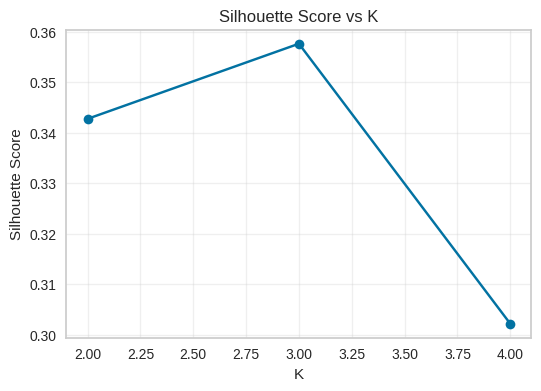

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(k_values, [r[2] for r in results], marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.show()

The Silhouette vs K curve shows a peak at K = 3.
This confirms that at K = 3, clusters achieve maximum separation before the quality decreases at K = 4

---



In [ ]:
# Determine best K
best_silhouette = -1
best_k = None

for k, wss, sil in results:
    if sil > best_silhouette:
        best_silhouette = sil
        best_k = k

print(f"\n✔ Optimal K based on Silhouette = {best_k}")


✔ Optimal K based on Silhouette = 3


### 🔍 K-Means Evaluation Summary

| K Value | Average Silhouette Score | Total Within-Cluster Sum of Squares (WSS) |
|---------|--------------------------|-------------------------------------------|
| 2       | 0.3427                   | 30967.25                                  |
| 3       | 0.3576                   | 22734.42                                  |
| 4       | 0.3022                   | 18871.12                                  |

**Interpretation:**

- **K=3** achieves the highest silhouette score → best separation between clusters.
- **K=4** has the lowest WSS → most compact clusters, but less separation.
- **K=2** has high WSS → less compact clusters.

📌 **Final Choice:** We choose **K = 3** because separation is more important than compactness for this dataset.

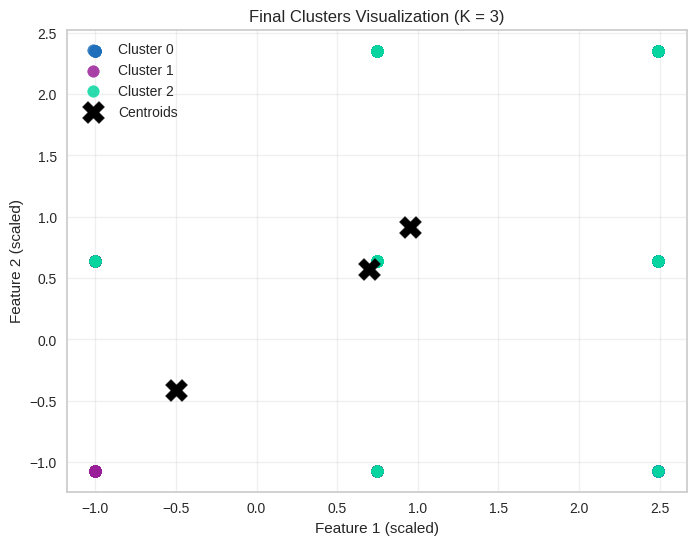

In [ ]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
final_labels = final_model.fit_predict(X_scaled)
centers = final_model.cluster_centers_

plt.figure(figsize=(8,6))
for i in range(best_k):
    plt.scatter(
        X_scaled[final_labels == i, 0],
        X_scaled[final_labels == i, 1],
        s=70,
        color=custom_colors[i],
        label=f"Cluster {i}",
        alpha=0.85
    )

plt.scatter(centers[:,0], centers[:,1], c="black", s=250, marker="X", label="Centroids")

plt.title(f"Final Clusters Visualization (K = {best_k})")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 📌 Interpretation of Clustering Results

We tested three different cluster sizes: K = 2, 3, and 4.  
Based on the Silhouette Scores, **K = 3 achieved the best separation between clusters** (highest silhouette value), indicating that the clusters are more distinct from each other compared to K = 2 and K = 4.

Although K = 4 had the lowest WSS value, meaning clusters were more compact, it also had the lowest silhouette score, showing poor separation and overlap between clusters. On the other hand, K = 2 showed high WSS, meaning clusters were not very compact and more spread out.

Therefore, **K = 3 is chosen as the optimal value** because it offers a good balance between compactness (lower WSS than K = 2) and separation (higher silhouette than K = 4).

Each cluster represents a different pollution pattern in the dataset:
- **Cluster 0:** Higher levels of pollutants indicating more polluted areas.  
- **Cluster 1:** Lower pollution readings across most features.  
- **Cluster 2:** Moderate values but specific spikes in certain pollutants.

## 8. References

[1] M. Matin, “Air Quality and Pollution Assessment Dataset,” Kaggle, 2023.[Online]. Available: https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment

[2] A. Sankar, T. K., et al.,“An optimized regression model for air quality index prediction using grey wolf optimization and decision tree regression,”Scientific Reports, vol. 14, no. 6795, 2024.
[Online]. Available: https://doi.org/10.1038/s41598-024-54807-1

[3] “Labs and Lecture Slides,” College of Computer Science and Information Technology, King Saud University, 2025.

[4] ChatGPT, OpenAI.[Online]. Available: https://chatgpt.com/